# Analisando investimentos

In [1]:
# Importar bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import yfinance as yf
import math

In [2]:
# Lendo o arquivo
caminho = 'Arquivo_Graham.xlsx'
file = pd.ExcelFile(caminho)
abas = file.sheet_names
abas

['Bolsa Graham', 'valor_investido_vs_investimento', 'Compras']

In [3]:
contador = 0 
while contador < 3:
    for guia in abas:
        if contador == 0:
            df_precos = pd.read_excel(caminho,sheet_name=guia, engine = "openpyxl")
            contador += 1
        elif contador ==1:
            df_valor_investido_investimento = pd.read_excel(caminho,sheet_name=guia, engine = "openpyxl")
            contador += 1
        else:
            df_valor_compras = pd.read_excel(caminho,sheet_name=guia, engine = "openpyxl")
            contador += 1
    

In [4]:
df_precos

,Date,STBP3.SA,KLBN4.SA,WHRL3.SA,REDE3.SA,BEEF3.SA,CEAB3.SA,VAMO3.SA,POMO4.SA,RADL3.SA,TECN3.SA
0,2000-01-31,0.000000,0.000000,0.128088,0.360784,0.00,0.000000,0.000000,0.148647,0.004700,0.000000
1,2000-02-29,0.000000,0.000000,0.128088,0.403921,0.00,0.000000,0.000000,0.212352,0.005372,0.000000
2,2000-03-31,0.000000,0.000000,0.126147,0.478431,0.00,0.000000,0.000000,0.178225,0.005372,0.000000
3,2000-04-30,0.000000,0.000000,0.116443,0.396862,0.00,0.000000,0.000000,0.197185,0.005372,0.000000
4,2000-05-31,0.000000,0.000000,0.116443,0.392156,0.00,0.000000,0.000000,0.214628,0.005372,0.000000
...,...,...,...,...,...,...,...,...,...,...,...
295,2024-08-31,11.157625,4.247353,3.921557,6.628304,7.49,9.734533,7.247877,7.024553,27.341482,5.196373
296,2024-09-30,12.668196,4.091486,4.409856,6.580959,6.34,10.050403,6.303746,7.597985,25.287897,4.689177
297,2024-10-31,12.585632,4.062262,3.996732,6.401048,5.80,12.472071,5.998572,8.085403,24.268383,5.215512
298,2024-11-30,12.774965,4.359582,3.996732,6.339721,5.85,10.117405,5.521738,8.331401,23.969267,5.646151


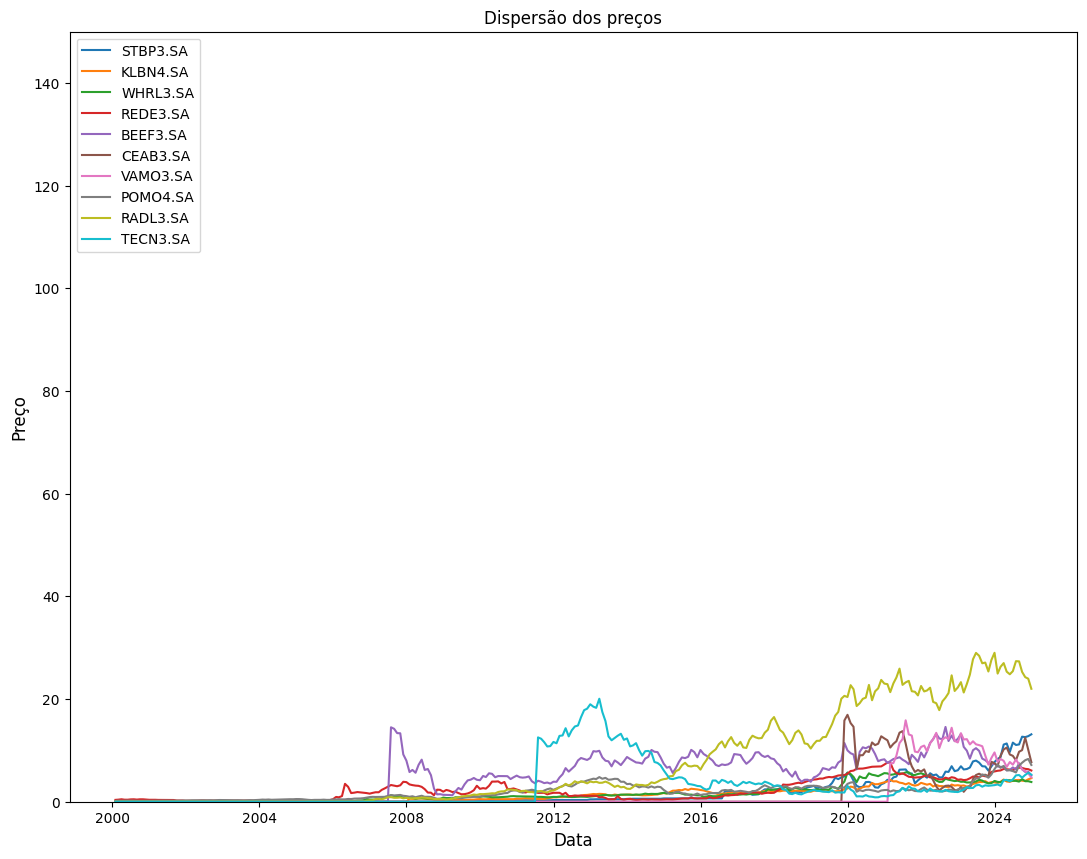

In [5]:
df_precos['Date'] = pd.to_datetime(df_precos['Date'])

plt.figure(figsize=(13,10))
# Para plotar n precisa criar dicionario ou algo do gerando o proprio plt vai implementando
for coluna in df_precos.columns[1:]:
    plt.plot(df_precos['Date'], df_precos[coluna], label=coluna)
plt.title('Dispersão dos preços', fontsize=12)
plt.ylim(0, 150)
plt.xlabel('Data', fontsize=12)
plt.ylabel('Preço', fontsize=12)
plt.legend(loc='upper left', fontsize=10) 
plt.show()

# oq eu preciso fazer
 - Preciso dos desvios padrões dos ativos
 - retono dos ativos
 - Preciso da correlação entre os ativos, descorbrir um jeito de calcular
 - preciso pegar o valor da ultima linha do preco de cada ativo para calcular o valor da carteira
- Com o valor carteira determinar o percentual de cada ativo na carteira e calcular o retorno esperado
- Depois calcular o risco do portifolio defir uma função que faça isso
- retorno esperado
Calcular o indice sharp , utilizando inflação e selic media
- Calcular a renda anual que a carteira teria
Calcular o ganho de capital
retorno levar em consideração o retorno logaritimo pegar no livro do assaf neto depois (TCC escrito)


In [6]:
array = np.array([df_precos[acao].values for acao in df_precos.columns[1:]])
df_precos.set_index('Date', inplace=True)

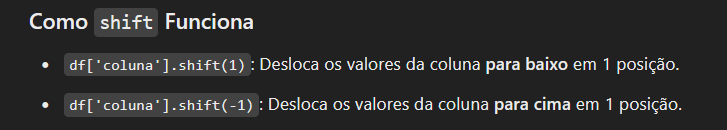

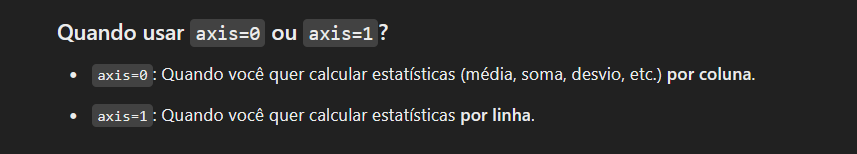

In [7]:
desvio_padro = np.std(array, axis=1)
desvio_padro

array([2.79416989, 1.33910861, 1.64540023, 2.07744565, 4.03410116,
       3.67995645, 3.79959947, 1.63045473, 9.09902244, 4.42555811])

In [8]:
# Ver quantos meses cada acao ficou em negociação para, para definir o retorno anual
dict_ano_negociado = {}
for acao in df_valor_compras['Acao']:
    dict_ano_negociado[acao]= (df_precos[df_precos[acao]!=0][acao].count())/12
dict_ano_negociado

{'STBP3.SA': np.float64(15.916666666666666),
 'KLBN4.SA': np.float64(17.0),
 'WHRL3.SA': np.float64(25.0),
 'REDE3.SA': np.float64(25.0),
 'BEEF3.SA': np.float64(17.5),
 'CEAB3.SA': np.float64(5.166666666666667),
 'VAMO3.SA': np.float64(3.9166666666666665),
 'POMO4.SA': np.float64(25.0),
 'RADL3.SA': np.float64(25.0),
 'TECN3.SA': np.float64(13.5)}

In [9]:
dict_retornos = {}
for acao in df_valor_compras['Acao']:
    retorno_logaritimo_soma = np.log(df_precos[acao].replace(0,np.nan)/df_precos[acao].replace(0,np.nan).shift(1)).sum()
    vezes_multi_capital = np.exp(retorno_logaritimo_soma)-1
    retorno_anual = (1+vezes_multi_capital)**(1/dict_ano_negociado[acao])-1
    dict_retornos[acao]= retorno_anual*100
dict_retornos

{'STBP3.SA': np.float64(27.856839806112333),
 'KLBN4.SA': np.float64(12.73950240437076),
 'WHRL3.SA': np.float64(14.570532968493266),
 'REDE3.SA': np.float64(11.960268096528104),
 'BEEF3.SA': np.float64(-5.8053704619070885),
 'CEAB3.SA': np.float64(-12.992797891101137),
 'VAMO3.SA': np.float64(-10.807261212443809),
 'POMO4.SA': np.float64(16.762949608851628),
 'RADL3.SA': np.float64(40.22062667031876),
 'TECN3.SA': np.float64(-6.210733423638459)}

In [10]:
# Calcular correlações
df_corre = df_precos[[colunas for colunas in df_precos.columns if colunas != 'Date']].replace(0,np.nan)
df_corre

,STBP3.SA,KLBN4.SA,WHRL3.SA,REDE3.SA,BEEF3.SA,CEAB3.SA,VAMO3.SA,POMO4.SA,RADL3.SA,TECN3.SA
Date,,,,,,,,,,
2000-01-31,NaN,NaN,0.128088,0.360784,NaN,NaN,NaN,0.148647,0.004700,NaN
2000-02-29,NaN,NaN,0.128088,0.403921,NaN,NaN,NaN,0.212352,0.005372,NaN
2000-03-31,NaN,NaN,0.126147,0.478431,NaN,NaN,NaN,0.178225,0.005372,NaN
2000-04-30,NaN,NaN,0.116443,0.396862,NaN,NaN,NaN,0.197185,0.005372,NaN
2000-05-31,NaN,NaN,0.116443,0.392156,NaN,NaN,NaN,0.214628,0.005372,NaN
...,...,...,...,...,...,...,...,...,...,...
2024-08-31,11.157625,4.247353,3.921557,6.628304,7.49,9.734533,7.247877,7.024553,27.341482,5.196373
2024-09-30,12.668196,4.091486,4.409856,6.580959,6.34,10.050403,6.303746,7.597985,25.287897,4.689177
2024-10-31,12.585632,4.062262,3.996732,6.401048,5.80,12.472071,5.998572,8.085403,24.268383,5.215512


In [11]:
correlacao = df_corre.corr()
correlacao

,STBP3.SA,KLBN4.SA,WHRL3.SA,REDE3.SA,BEEF3.SA,CEAB3.SA,VAMO3.SA,POMO4.SA,RADL3.SA,TECN3.SA
STBP3.SA,1.000000,0.857589,0.761301,0.770025,0.290477,-0.008871,-0.629752,0.667404,0.877372,-0.443413
KLBN4.SA,0.857589,1.000000,0.888929,0.713238,0.557693,0.160850,-0.769696,0.557859,0.942064,-0.624346
WHRL3.SA,0.761301,0.888929,1.000000,0.868738,0.426451,0.522729,0.260646,0.607569,0.939740,-0.614969
REDE3.SA,0.770025,0.713238,0.868738,1.000000,0.169920,0.695827,-0.761907,0.555986,0.830420,-0.588977
BEEF3.SA,0.290477,0.557693,0.426451,0.169920,1.000000,-0.452042,0.738447,0.128812,0.416703,-0.186690
CEAB3.SA,-0.008871,0.160850,0.522729,0.695827,-0.452042,1.000000,-0.484468,0.146804,0.044622,-0.007553
VAMO3.SA,-0.629752,-0.769696,0.260646,-0.761907,0.738447,-0.484468,1.000000,-0.742199,-0.313518,-0.664659
POMO4.SA,0.667404,0.557859,0.607569,0.555986,0.128812,0.146804,-0.742199,1.000000,0.677269,0.256854
RADL3.SA,0.877372,0.942064,0.939740,0.830420,0.416703,0.044622,-0.313518,0.677269,1.000000,-0.690082
TECN3.SA,-0.443413,-0.624346,-0.614969,-0.588977,-0.186690,-0.007553,-0.664659,0.256854,-0.690082,1.000000


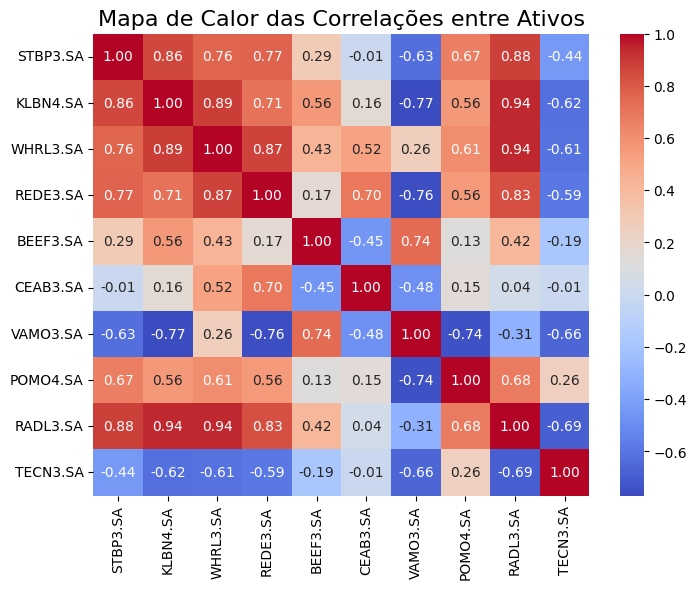

In [12]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlacao, annot=True, cmap='coolwarm', fmt=".2f", cbar=True)

# Personalizando o gráfico
plt.title('Mapa de Calor das Correlações entre Ativos', fontsize=16)
plt.show()

In [13]:
desvio_padro

array([2.79416989, 1.33910861, 1.64540023, 2.07744565, 4.03410116,
       3.67995645, 3.79959947, 1.63045473, 9.09902244, 4.42555811])

In [14]:
dict_desvio = {acao:0 for acao in df_valor_compras['Acao']}
contador = 0
for acao in df_valor_compras['Acao']:
    dict_desvio[acao]= desvio_padro[contador]
    contador +=1
dict_desvio

{'STBP3.SA': np.float64(2.794169891704343),
 'KLBN4.SA': np.float64(1.3391086109195014),
 'WHRL3.SA': np.float64(1.645400227793211),
 'REDE3.SA': np.float64(2.0774456495758002),
 'BEEF3.SA': np.float64(4.034101156301557),
 'CEAB3.SA': np.float64(3.6799564471364303),
 'VAMO3.SA': np.float64(3.7995994716337074),
 'POMO4.SA': np.float64(1.6304547272003522),
 'RADL3.SA': np.float64(9.099022437678475),
 'TECN3.SA': np.float64(4.425558110773552)}

In [15]:
df_precos_final = df_precos[[colunas for colunas in df_precos.columns if colunas != 'Date']].tail(1)
df_precos_final

,STBP3.SA,KLBN4.SA,WHRL3.SA,REDE3.SA,BEEF3.SA,CEAB3.SA,VAMO3.SA,POMO4.SA,RADL3.SA,TECN3.SA
Date,,,,,,,,,,
2024-12-31,13.13,4.59,3.84,6.079185,5.09,7.705309,4.75,7.157827,22.0,5.272931


In [16]:
dict_valor_ativo = {}
contador = 0
while contador < len(df_valor_compras):
    acao = qtd=df_valor_compras.loc[contador,'Acao']
    qtd=df_valor_compras.loc[contador,'Qtd_comprada']
    dict_valor_ativo[acao]=qtd
    contador += 1
dict_valor_ativo
        

{'STBP3.SA': np.int64(639),
 'KLBN4.SA': np.int64(623),
 'WHRL3.SA': np.int64(2450),
 'REDE3.SA': np.int64(2353),
 'BEEF3.SA': np.int64(455),
 'CEAB3.SA': np.int64(70),
 'VAMO3.SA': np.int64(47),
 'POMO4.SA': np.int64(2275),
 'RADL3.SA': np.int64(2425),
 'TECN3.SA': np.int64(195)}

In [17]:
valor_total = 0
porcentagem_ativo = {}
for acao in dict_valor_ativo.keys():
    preco = df_precos_final[acao].values
    qtd = dict_valor_ativo[acao]
    valor_total += preco*qtd
print(valor_total)


[108702.81170321]


In [18]:
porcentagem_ativo = {}
for acao in dict_valor_ativo.keys():
    preco = df_precos_final[acao].values
    qtd = dict_valor_ativo[acao]
    porcentagem_ativo[acao]= (preco*qtd)/valor_total
porcentagem_ativo

{'STBP3.SA': array([0.07718356]),
 'KLBN4.SA': array([0.02630631]),
 'WHRL3.SA': array([0.0865479]),
 'REDE3.SA': array([0.13159109]),
 'BEEF3.SA': array([0.02130534]),
 'CEAB3.SA': array([0.00496189]),
 'VAMO3.SA': array([0.00205376]),
 'POMO4.SA': array([0.14980346]),
 'RADL3.SA': array([0.49078767]),
 'TECN3.SA': array([0.00945902])}

In [19]:
def variancia_risco_port(participacao_1,participacao_2,delta_1,delta_2,corr_1_2):
    variancia = participacao_1*participacao_2*delta_1*delta_2*corr_1_2
    return variancia

In [20]:
correlacao

,STBP3.SA,KLBN4.SA,WHRL3.SA,REDE3.SA,BEEF3.SA,CEAB3.SA,VAMO3.SA,POMO4.SA,RADL3.SA,TECN3.SA
STBP3.SA,1.000000,0.857589,0.761301,0.770025,0.290477,-0.008871,-0.629752,0.667404,0.877372,-0.443413
KLBN4.SA,0.857589,1.000000,0.888929,0.713238,0.557693,0.160850,-0.769696,0.557859,0.942064,-0.624346
WHRL3.SA,0.761301,0.888929,1.000000,0.868738,0.426451,0.522729,0.260646,0.607569,0.939740,-0.614969
REDE3.SA,0.770025,0.713238,0.868738,1.000000,0.169920,0.695827,-0.761907,0.555986,0.830420,-0.588977
BEEF3.SA,0.290477,0.557693,0.426451,0.169920,1.000000,-0.452042,0.738447,0.128812,0.416703,-0.186690
CEAB3.SA,-0.008871,0.160850,0.522729,0.695827,-0.452042,1.000000,-0.484468,0.146804,0.044622,-0.007553
VAMO3.SA,-0.629752,-0.769696,0.260646,-0.761907,0.738447,-0.484468,1.000000,-0.742199,-0.313518,-0.664659
POMO4.SA,0.667404,0.557859,0.607569,0.555986,0.128812,0.146804,-0.742199,1.000000,0.677269,0.256854
RADL3.SA,0.877372,0.942064,0.939740,0.830420,0.416703,0.044622,-0.313518,0.677269,1.000000,-0.690082
TECN3.SA,-0.443413,-0.624346,-0.614969,-0.588977,-0.186690,-0.007553,-0.664659,0.256854,-0.690082,1.000000


In [21]:
variacia_port = 0
for acao_1 in df_valor_compras['Acao']:
    for acao_2 in df_valor_compras['Acao']:
        participacao_1 = porcentagem_ativo[acao_1]
        participacao_2 = porcentagem_ativo[acao_2]
        desv_padro_1 = dict_desvio[acao_1]
        desv_padro_2 = dict_desvio[acao_2]
        corre = correlacao.loc[acao_1,acao_2]
        variacia_port +=variancia_risco_port(participacao_1,participacao_2,desv_padro_1,desv_padro_2,corre)
desv_pad_port=variacia_port**(1/2)
desv_pad_port

array([5.22865297])

# Quando se junta 2 arrays em um terceiro eles apenas pegam cada array e transforma numa dimensaõ de um terceiro, para juntar 2 arrays em 1 só é necessario concatenar
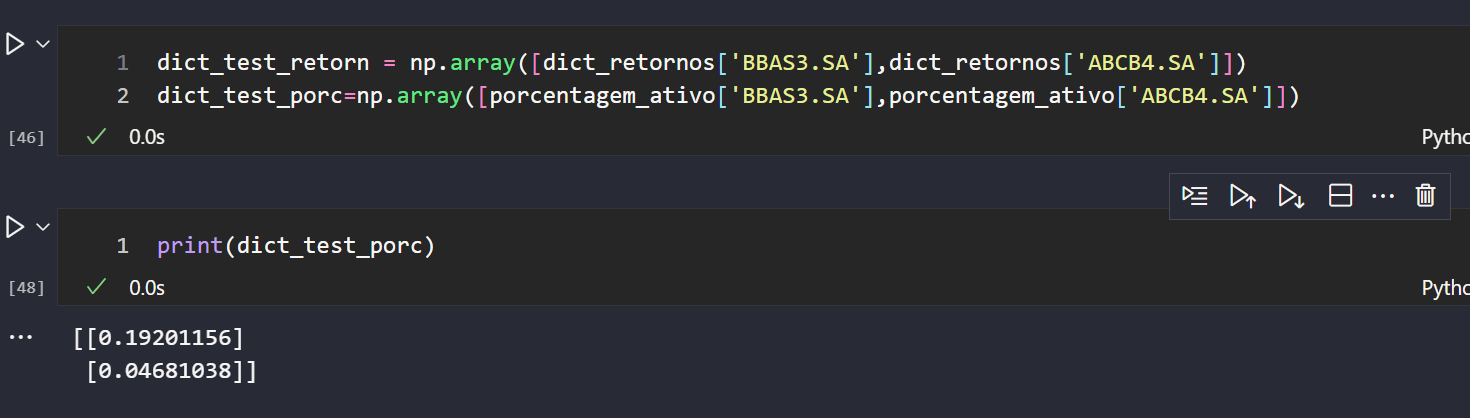

In [22]:
retornos = np.array([dict_retornos[acao] for acao in dict_retornos.keys()])
porcentagens=np.concatenate([porcentagem_ativo[acao] for acao in porcentagem_ativo.keys()])

In [23]:
print(retornos,porcentagens)

[ 27.85683981  12.7395024   14.57053297  11.9602681   -5.80537046
 -12.99279789 -10.80726121  16.76294961  40.22062667  -6.21073342] [0.07718356 0.02630631 0.0865479  0.13159109 0.02130534 0.00496189
 0.00205376 0.14980346 0.49078767 0.00945902]


In [24]:
retorno_esperado = sum(retornos*porcentagens)
retorno_esperado

np.float64(27.301971476544153)

In [25]:
df_valor_investido_investimento

,Nome,Valor
0,carteira_contabil_graham,14972.697259
1,valor_investido_graham,14973.120000


In [26]:
Total_capital_faltou_investir = df_valor_investido_investimento.loc[1,'Valor',] - df_valor_investido_investimento.loc[0,'Valor',] 
Total_capital_faltou_investir

np.float64(0.4227406428090035)

In [27]:
ganho_capital = valor_total - df_valor_investido_investimento.loc[1,'Valor',]
ganho_capital

array([93729.69170321])

In [28]:
contador = 0
valor_recebido_total = 0
while contador < len(df_valor_compras):
    for acao in df_valor_compras['Acao']:
        empresa = yf.Ticker(acao)
        dividendos = empresa.dividends
        if not dividendos.empty:
            dividendos_anuais_geral = dividendos.groupby(dividendos.index.year).sum()
            dividendo_ultimo_ano = dividendos_anuais_geral.tail(1)
            valor_pago = df_valor_compras.loc[contador, 'Qtd_comprada'] * dividendo_ultimo_ano.values
            valor_recebido_total+= valor_pago
            print(dividendo_ultimo_ano,valor_pago)
        else:
            valor_pago = 0  
        contador +=1
valor_recebido_total
        

Date
2024    2.602775
Name: Dividends, dtype: float64 [1663.173225]
Date
2024    0.265707
Name: Dividends, dtype: float64 [165.535461]
Date
2024    0.379493
Name: Dividends, dtype: float64 [929.75785]
Date
2025    0.245
Name: Dividends, dtype: float64 [576.485]
Date
2023    0.550902
Name: Dividends, dtype: float64 [250.66041]
Date
2025    0.344691
Name: Dividends, dtype: float64 [24.12837]
Date
2024    0.268262
Name: Dividends, dtype: float64 [12.608314]
Date
2025    0.23
Name: Dividends, dtype: float64 [523.25]
Date
2024    0.338046
Name: Dividends, dtype: float64 [819.76155]
Date
2025    0.23879
Name: Dividends, dtype: float64 [46.56405]


array([5011.92423])

In [29]:
SELIC_MEDIA = 12.15999870500932
DESV_PAD_SELIC = 4.793701588763131
INFLACAO = 6.18

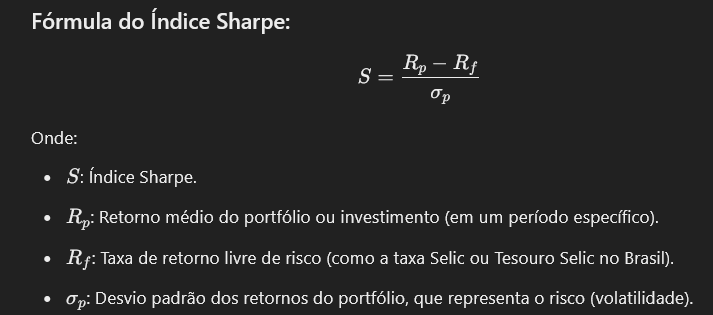

In [30]:
print(retorno_esperado,desv_pad_port,INFLACAO,SELIC_MEDIA,DESV_PAD_SELIC)

27.301971476544153 [5.22865297] 6.18 12.15999870500932 4.793701588763131


In [31]:
indice_sharpe_inflação = (retorno_esperado - INFLACAO)/desv_pad_port
indice_sharpe_inflação

print(f'Oferece um retorono de {indice_sharpe_inflação} para cada unidade de risco assumido')

Oferece um retorono de [4.03965832] para cada unidade de risco assumido


In [35]:
# Para taxa que sofre grandes variações pode se considerar o desvio padrao desse retorno no indice sharpe
# Devido a cenario de economia emergente e longo prazo gera essa variação

indice_sharpe_selic = (retorno_esperado-SELIC_MEDIA)/desv_pad_port[0]
indice_sharpe_selic
print(f'Oferece um retorono de {indice_sharpe_selic} para cada unidade de risco assumido')

Oferece um retorono de 2.8959605571778653 para cada unidade de risco assumido


In [36]:
dados = {'risco_portifolio':desv_pad_port, 'Retorno_portifolio':retorno_esperado,
         'Indice_sharpe_inflacao':indice_sharpe_inflação,
         'indice_sharpe_selic':indice_sharpe_selic, 'Dividendos':valor_recebido_total
         ,'ganho_capital':ganho_capital,
         }
dados_df=pd.DataFrame(dados)

In [37]:
with pd.ExcelWriter('base_analise_graham.xlsx',engine='openpyxl') as writer:
        dados_df.to_excel(writer,sheet_name='Analise', index=False)
